In [ ]:
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense,Activation
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
# df=pd.read_csv('C:\\My Files\\ANN & ML Projects\\ANNDL_Fall_2026\\Project_ANNDL_Fall_2026\\data\\processed\\Images28.csv')
# X=df.drop(df.columns[0],axis=1).values
# Y=df.drop(df.columns[1:],axis=1).values

# trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, random_state=42)

# print(trainX.shape,trainY.shape)
# print(testX.shape,testY.shape)
# print(trainY)

(15999, 2352) (15999, 1)
(4000, 2352) (4000, 1)
[[1]
 [0]
 [1]
 ...
 [1]
 [0]
 [3]]


In [ ]:
# trainX=trainX.reshape(15999,2352)
# testX=testX.reshape(4000,2352)
# trainY=to_categorical(trainY,10)
# testY=to_categorical(testY,10)

TypeError: Invalid shape (2352,) for image data

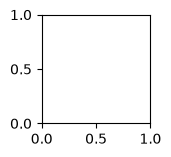

In [ ]:
# plt.figure()
# for i in range(9):
#     plt.subplot(3,3,i+1)
#     plt.imshow(trainX[i],cmap='gray')
#     plt.title('Label: %d' % trainY[i].argmax())
#     plt.axis('off')

Train shapes: X=(15999, 2352), Y=(15999, 10)
Test shapes:  X=(4000, 2352), Y=(4000, 10)


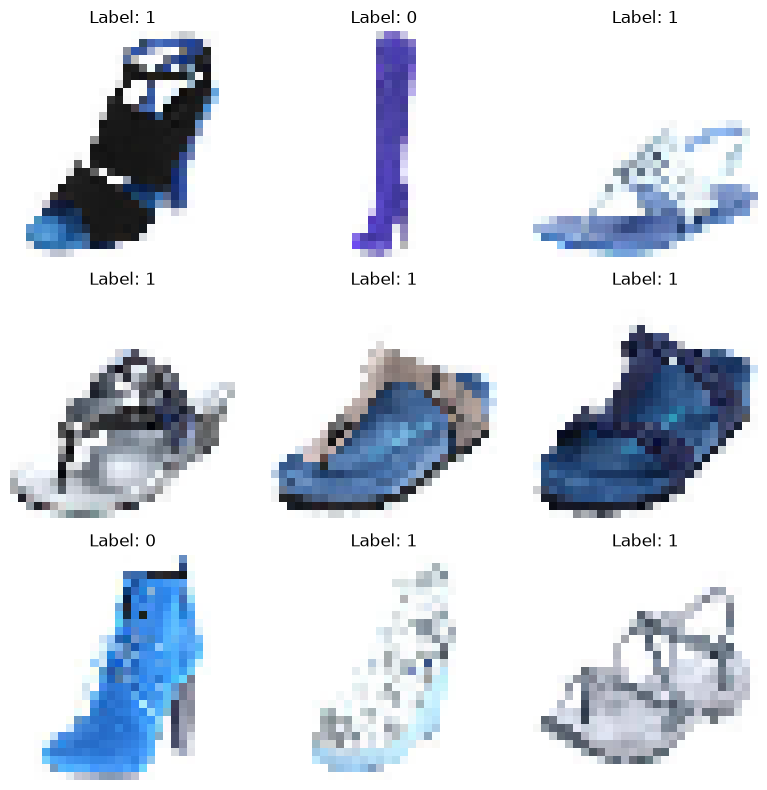

c:\Users\raoaf\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7921 - loss: 0.5276 - val_accuracy: 0.8425 - val_loss: 0.3974
Epoch 2/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8656 - loss: 0.3505 - val_accuracy: 0.8900 - val_loss: 0.3158
Epoch 3/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8888 - loss: 0.2986 - val_accuracy: 0.8706 - val_loss: 0.3386
Epoch 4/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8932 - loss: 0.2843 - val_accuracy: 0.9056 - val_loss: 0.2566
Epoch 5/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9141 - loss: 0.2377 - val_accuracy: 0.8963 - val_loss: 0.2697
Epoch 6/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9137 - loss: 0.2352 - val_accuracy: 0.9038 - val_loss: 0.2597
Epoch 7/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9188 - loss: 0.2214 - val_accuracy: 0.8600 - val_loss: 0.3757
Epoch 8/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9194 - loss: 0.2165 - val_accuracy: 0

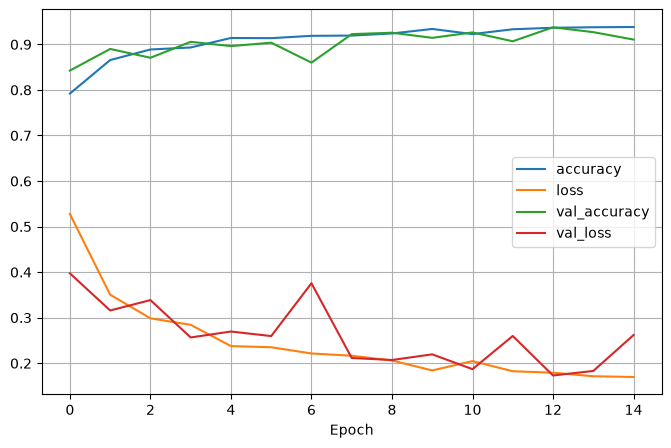

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

df = pd.read_csv(r'C:\My Files\ANN & ML Projects\ANNDL_Fall_2026\Project_ANNDL_Fall_2026\data\processed\Images28.csv')

Y = df.iloc[:, 0].values
X = df.iloc[:, 1:].values / 255.0

# 3. Split Dataset
trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, random_state=42)

# 4. One-Hot Encode Target Labels (0-9)
trainY_cat = to_categorical(trainY, num_classes=10)
testY_cat = to_categorical(testY, num_classes=10)

print(f"Train shapes: X={trainX.shape}, Y={trainY_cat.shape}")
print(f"Test shapes:  X={testX.shape}, Y={testY_cat.shape}")

# 5. Plot Sample Images (Reshape flat 2352 features to 28x28x3 RGB)
plt.figure()
for i in range(9):
    plt.subplot(3, 3, i + 1)
    # Reshape 2352 flat array back to (28, 28, 3) for plotting
    img = trainX[i].reshape(28, 28, 3)
    plt.imshow(img)
    plt.title(f'Label: {trainY[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

# 6. Build Neural Network Model
model = Sequential([
    Dense(128, input_dim=2352, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# 7. Compile & Train Model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(trainX, trainY_cat, epochs=15, batch_size=64, validation_split=0.1, verbose=1)

# 8. Evaluate Performance
loss, accuracy = model.evaluate(testX, testY_cat, verbose=0)
print(f'\nTest Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

# 9. Plot Training Loss and Accuracy History
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epoch")
plt.show()

# 10. Save Trained Model
model.save('mnist_rgb_model.h5')